In [ ]:
!pip install torch_geometric ogb

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.convs.append(GCNConv(hidden_channels, out_channels))

        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return x

In [2]:
from ogb.linkproppred import PygLinkPropPredDataset
import torch
import numpy as np

def get_ogbl_collab_data():
  _original_load = torch.load
  # Overwrite torch.load to default weights_only to False
  def _patched_load(f, **kwargs):
      kwargs["weights_only"] = False
      return _original_load(f, **kwargs)

  torch.load = _patched_load

  dataset = PygLinkPropPredDataset(name="ogbl-collab")
  split_edge = dataset.get_edge_split()

  return dataset, dataset[0], split_edge

dataset, data, split_edges = get_ogbl_collab_data()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

Downloaded 0.11 GB: 100%|██████████| 117/117 [00:01<00:00, 72.62it/s]


Extracting dataset/collab.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 40.81it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 457.24it/s]

Saving...



Done!


In [3]:
train_edges    = split_edges['train']['edge'].to(device)
val_edges_pos  = split_edges['valid']['edge'].to(device)
val_edges_neg  = split_edges['valid']['edge_neg'].to(device)
test_edges_pos = split_edges['test']['edge'].to(device)
test_edges_neg = split_edges['test']['edge_neg'].to(device)

print(f"val_edges_neg shape:  {val_edges_neg.shape}")
print(f"test_edges_neg shape: {test_edges_neg.shape}")
print(f"Train edges: {train_edges.shape}")
print(f"Val edges: {val_edges_pos.shape}")
print(f"Test edges: {test_edges_pos.shape}")

def score_edges(z, edges):
    """Dot product score for a set of edges."""
    return (z[edges[:, 0]] * z[edges[:, 1]]).sum(dim=-1)

val_edges_neg shape:  torch.Size([100000, 2])
test_edges_neg shape: torch.Size([100000, 2])
Train edges: torch.Size([1179052, 2])
Val edges: torch.Size([60084, 2])
Test edges: torch.Size([46329, 2])


In [4]:
from torch_geometric.utils import negative_sampling
from ogb.linkproppred import PygLinkPropPredDataset, Evaluator
import time

evaluator = Evaluator(name='ogbl-collab')

def train(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    z = model(data.x, data.edge_index)

    # Positive edges
    pos_score = score_edges(z, train_edges)

    # Sample negative edges
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=train_edges.size(0)
    )
    neg_score = score_edges(z, neg_edge_index.t())

    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([
        torch.ones(pos_score.size(0)),
        torch.zeros(neg_score.size(0))
    ]).to(device)

    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    z = model(data.x, data.edge_index)

    results = {}
    for split, pos, neg in [
        ('valid', val_edges_pos, val_edges_neg),
        ('test',  test_edges_pos, test_edges_neg)
    ]:
        pos_score = score_edges(z, pos)
        neg_score = score_edges(z, neg)

        hits = evaluator.eval({
            'y_pred_pos': pos_score,
            'y_pred_neg': neg_score,
        })
        results[split] = hits['hits@50']

    return results

In [5]:
model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=256,
    out_channels=64,
    num_layers=3,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print(model)
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")

GCN(
  (convs): ModuleList(
    (0): GCNConv(128, 256)
    (1): GCNConv(256, 256)
    (2): GCNConv(256, 64)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
Num parameters: 116,288


In [6]:
history = {
    'epoch': [],
    'loss': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': []
}

In [7]:
NUM_EPOCHS = 500
best_val  = 0
best_test = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t = time.time()
    loss = train(model, optimizer, criterion)
    elapsed = time.time() - t
    scheduler.step()

    if epoch % 10 == 0:
        results = evaluate(model)

        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['val_acc'].append(results['valid'])
        history['test_acc'].append(results['test'])

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Val Hits@50: {results['valid']:.4f} | "
              f"Test Hits@50: {results['test']:.4f} | "
              f"Time: {elapsed:.2f}s")

        if results['valid'] > best_val:
            best_val  = results['valid']
            best_test = results['test']
            torch.save(model.state_dict(), 'best_gcn_link.pt')

print(f"\nBest Val  Hits@50: {best_val:.4f}")
print(f"Best Test Hits@50: {best_test:.4f}")

Epoch 010 | Loss: 0.7855 | Val Hits@50: 0.0407 | Test Hits@50: 0.0409 | Time: 1.72s
Epoch 020 | Loss: 0.6384 | Val Hits@50: 0.0183 | Test Hits@50: 0.0212 | Time: 1.73s
Epoch 030 | Loss: 0.5690 | Val Hits@50: 0.0163 | Test Hits@50: 0.0191 | Time: 1.74s
Epoch 040 | Loss: 0.5036 | Val Hits@50: 0.0221 | Test Hits@50: 0.0256 | Time: 1.73s
Epoch 050 | Loss: 0.4821 | Val Hits@50: 0.0375 | Test Hits@50: 0.0407 | Time: 1.77s
Epoch 060 | Loss: 0.4662 | Val Hits@50: 0.0600 | Test Hits@50: 0.0638 | Time: 1.77s
Epoch 070 | Loss: 0.4575 | Val Hits@50: 0.0679 | Test Hits@50: 0.0674 | Time: 1.76s
Epoch 080 | Loss: 0.4485 | Val Hits@50: 0.0872 | Test Hits@50: 0.0867 | Time: 1.76s
Epoch 090 | Loss: 0.4423 | Val Hits@50: 0.0816 | Test Hits@50: 0.0803 | Time: 1.80s
Epoch 100 | Loss: 0.4382 | Val Hits@50: 0.1040 | Test Hits@50: 0.0992 | Time: 1.79s
Epoch 110 | Loss: 0.4357 | Val Hits@50: 0.1314 | Test Hits@50: 0.1198 | Time: 1.76s
Epoch 120 | Loss: 0.4331 | Val Hits@50: 0.1566 | Test Hits@50: 0.1423 | Time

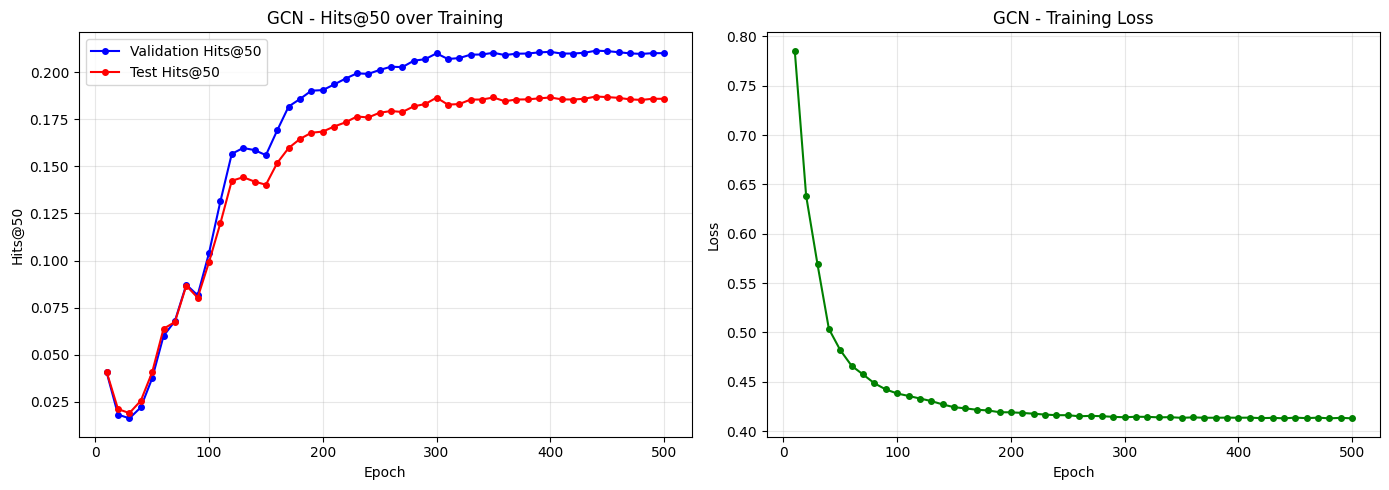

In [8]:
import matplotlib.pyplot as plt

epochs_logged = list(range(10, 501, 10))

val_accs = [
    0.0407, 0.0183, 0.0163, 0.0221, 0.0375,
    0.0600, 0.0679, 0.0872, 0.0816, 0.1040,
    0.1314, 0.1566, 0.1597, 0.1586, 0.1559,
    0.1691, 0.1817, 0.1857, 0.1901, 0.1904,
    0.1934, 0.1965, 0.1993, 0.1990, 0.2011,
    0.2028, 0.2026, 0.2060, 0.2068, 0.2099,
    0.2069, 0.2074, 0.2092, 0.2093, 0.2102,
    0.2090, 0.2097, 0.2098, 0.2104, 0.2107,
    0.2098, 0.2098, 0.2102, 0.2113, 0.2111,
    0.2105, 0.2099, 0.2096, 0.2100, 0.2100
]

test_accs = [
    0.0409, 0.0212, 0.0191, 0.0256, 0.0407,
    0.0638, 0.0674, 0.0867, 0.0803, 0.0992,
    0.1198, 0.1423, 0.1442, 0.1419, 0.1402,
    0.1518, 0.1597, 0.1645, 0.1678, 0.1684,
    0.1711, 0.1733, 0.1764, 0.1759, 0.1784,
    0.1793, 0.1788, 0.1818, 0.1830, 0.1864,
    0.1827, 0.1830, 0.1854, 0.1854, 0.1865,
    0.1845, 0.1854, 0.1855, 0.1860, 0.1865,
    0.1855, 0.1854, 0.1858, 0.1870, 0.1867,
    0.1863, 0.1855, 0.1852, 0.1858, 0.1858
]

losses = [
    0.7855, 0.6384, 0.5690, 0.5036, 0.4821,
    0.4662, 0.4575, 0.4485, 0.4423, 0.4382,
    0.4357, 0.4331, 0.4305, 0.4271, 0.4243,
    0.4231, 0.4217, 0.4210, 0.4192, 0.4191,
    0.4185, 0.4177, 0.4168, 0.4162, 0.4162,
    0.4151, 0.4155, 0.4152, 0.4145, 0.4141,
    0.4146, 0.4145, 0.4140, 0.4142, 0.4135,
    0.4140, 0.4136, 0.4136, 0.4137, 0.4136,
    0.4137, 0.4132, 0.4135, 0.4130, 0.4137,
    0.4132, 0.4137, 0.4130, 0.4135, 0.4130
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, val_accs, 'b-o', label='Validation Hits@50', markersize=4)
ax1.plot(epochs_logged, test_accs, 'r-o', label='Test Hits@50', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Hits@50')
ax1.set_title('GCN - Hits@50 over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GCN - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

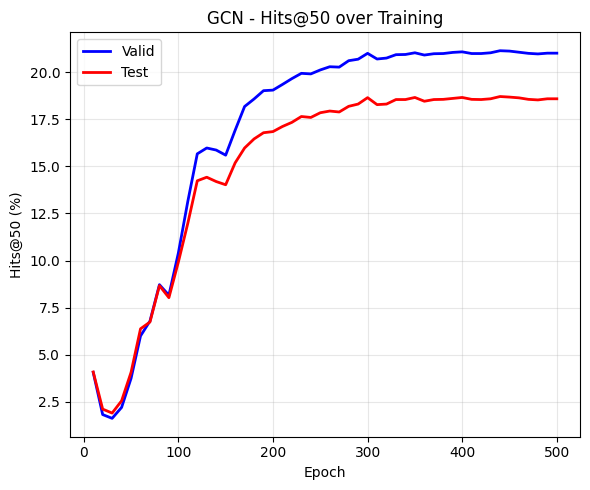

In [10]:
plt.figure(figsize=(6,5))

plt.plot(epochs_logged, [x*100 for x in val_accs], 'b-', label='Valid', linewidth=2)
plt.plot(epochs_logged, [x*100 for x in test_accs], 'r-', label='Test', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Hits@50 (%)')
plt.title('GCN - Hits@50 over Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
@torch.no_grad()
def get_scores_from_embeddings(h, predictor, split_edge, batch_size):
    predictor.eval()

    pos_edge = split_edge['test']['edge'].to(h.device)
    neg_edge = split_edge['test']['edge_neg'].to(h.device)

    pos_scores, neg_scores = [], []

    for perm in DataLoader(range(pos_edge.size(0)), batch_size):
        edge = pos_edge[perm].t()
        pos_scores.append(
            predictor(h[edge[0]], h[edge[1]]).squeeze().cpu()
        )

    for perm in DataLoader(range(neg_edge.size(0)), batch_size):
        edge = neg_edge[perm].t()
        neg_scores.append(
            predictor(h[edge[0]], h[edge[1]]).squeeze().cpu()
        )

    return torch.cat(pos_scores).numpy(), torch.cat(neg_scores).numpy()

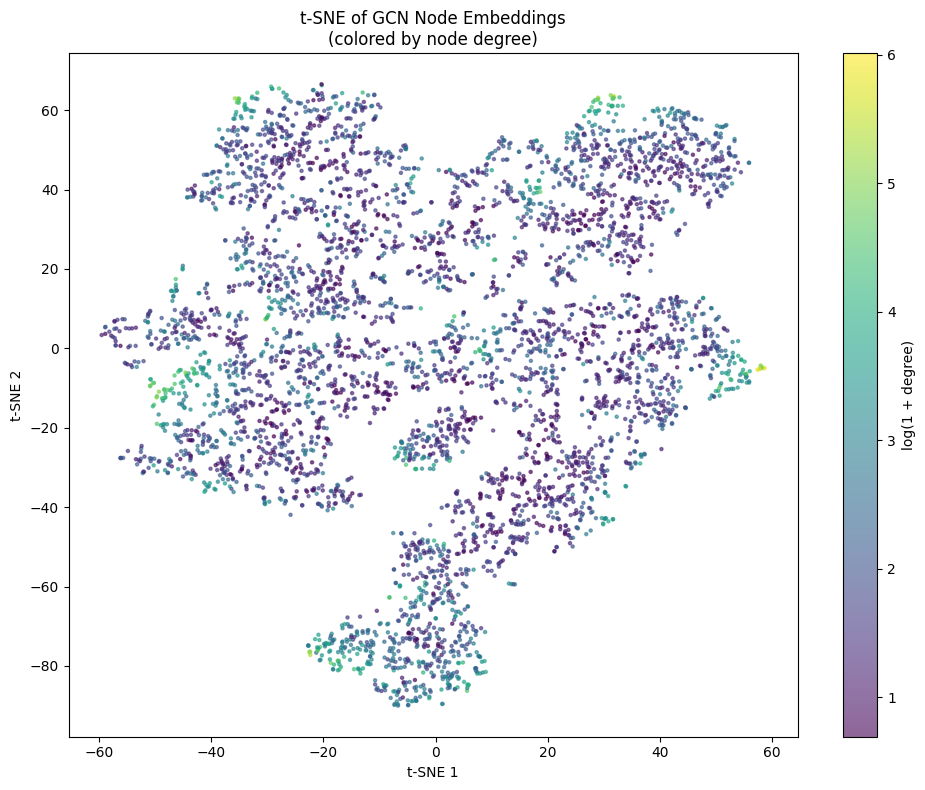

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

if 'embeddings' not in globals() or 'node_idx' not in globals():
    with torch.no_grad():
        model.eval()
        h = model(data.x, data.edge_index)

        num_nodes = min(5000, h.size(0))
        node_idx = torch.randperm(h.size(0))[:num_nodes]

        embeddings = h[node_idx].cpu().numpy()
        node_idx = node_idx.cpu().numpy()

src, dst = data.edge_index.cpu()
deg = torch.zeros(data.num_nodes, dtype=torch.long)
deg.scatter_add_(0, src, torch.ones_like(src))

sampled_degrees = deg[node_idx].numpy()

if 'embeddings_2d' not in globals():
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=np.log1p(sampled_degrees),
    cmap='viridis',
    s=5,
    alpha=0.6
)

plt.colorbar(scatter, ax=ax, label='log(1 + degree)')
ax.set_title('t-SNE of GCN Node Embeddings\n(colored by node degree)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()